# ***Task 3.2 — Failure Mode Analysis***

**Paper:** Pegasos: Primal Estimated sub-GrAdient SOlver for SVM  

## ***Failure Scenario: Linearly Non-Separable Data with Severely Imbalanced Classes***

***Why I expect the method to struggle:***  
*Pegasos is a linear SVM solver — it optimises a linear decision boundary in the original feature space. When the data is not linearly separable and requires a non-linear boundary (e.g., concentric circles, XOR-like patterns), a linear SVM will systematically fail regardless of the learning rate or regularisation. This failure is directly rooted in **Assumption 4 from Task 1.2**: Pegasos works in a finite-dimensional explicit feature space and cannot represent non-linear boundaries without an explicit kernel mapping. Additionally, combining non-separability with severe class imbalance exacerbates the problem: random mini-batch sampling (Assumption 3, uniform i.i.d. sampling) will rarely encounter the minority class, biasing updates towards the majority and producing a degenerate classifier that predicts one class for most inputs.*


In [1]:
SEED = 42

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.svm import SVC

np.random.seed(SEED)

LAMBDA = 1e-3
T      = 5000
K      = 1

X_circle, y_circle = make_circles(n_samples=1000, noise=0.1, factor=0.4, random_state=SEED)

idx_0 = np.where(y_circle == 0)[0]
idx_1 = np.where(y_circle == 1)[0]
idx_1_sub = np.random.choice(idx_1, size=50, replace=False)
idx_all = np.concatenate([idx_0, idx_1_sub])
np.random.shuffle(idx_all)
X_fail = X_circle[idx_all]
y_fail = np.where(y_circle[idx_all] == 0, -1, 1)

X_f_norm = normalize(X_fail, norm='l2')
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_f_norm, y_fail, test_size=0.2, random_state=SEED, stratify=y_fail
)

print(f"Failure dataset: {X_fail.shape[0]} samples, class balance: {np.bincount((y_fail+1)//2)}")

Failure dataset: 550 samples, class balance: [500  50]


In [2]:
def primal_obj(w, X, y, lam):
    return (lam / 2) * np.dot(w, w) + np.mean(np.maximum(0.0, 1.0 - y * (X @ w)))

def pegasos(X, y, lam, T, k, seed):
    rng = np.random.RandomState(seed)
    m, d = X.shape
    w = np.zeros(d)
    trace = []
    for t in range(1, T + 1):
        idx = rng.randint(0, m, size=k)
        X_b, y_b = X[idx], y[idx]
        eta = 1.0 / (lam * t)
        viol = (y_b * (X_b @ w)) < 1.0
        w = (1.0 - 1.0 / t) * w
        if viol.any():
            w += (eta / k) * (y_b[viol, np.newaxis] * X_b[viol]).sum(axis=0)
        nw = np.linalg.norm(w)
        if nw > 1.0 / np.sqrt(lam):
            w = (1.0 / (np.sqrt(lam) * nw)) * w
        if t % 10 == 0:
            trace.append((t, primal_obj(w, X, y, lam)))
    return w, trace

w_fail, trace_fail = pegasos(Xf_train, yf_train, LAMBDA, T, K, SEED)
yf_pred = np.sign(Xf_test @ w_fail)

svc = SVC(kernel='rbf', C=1.0, random_state=SEED)
svc.fit(Xf_train, yf_train)
yf_rbf_pred = svc.predict(Xf_test)

acc_pegasos = np.mean(yf_pred == yf_test) * 100
acc_rbf     = np.mean(yf_rbf_pred == yf_test) * 100
print(f"Pegasos (linear) accuracy on failure dataset : {acc_pegasos:.2f}%")
print(f"RBF SVM reference accuracy                   : {acc_rbf:.2f}%")
print(f"Predicted class distribution (Pegasos): {np.bincount((yf_pred.astype(int)+1)//2)}")

Pegasos (linear) accuracy on failure dataset : 47.27%
RBF SVM reference accuracy                   : 90.91%
Predicted class distribution (Pegasos): [56 54]


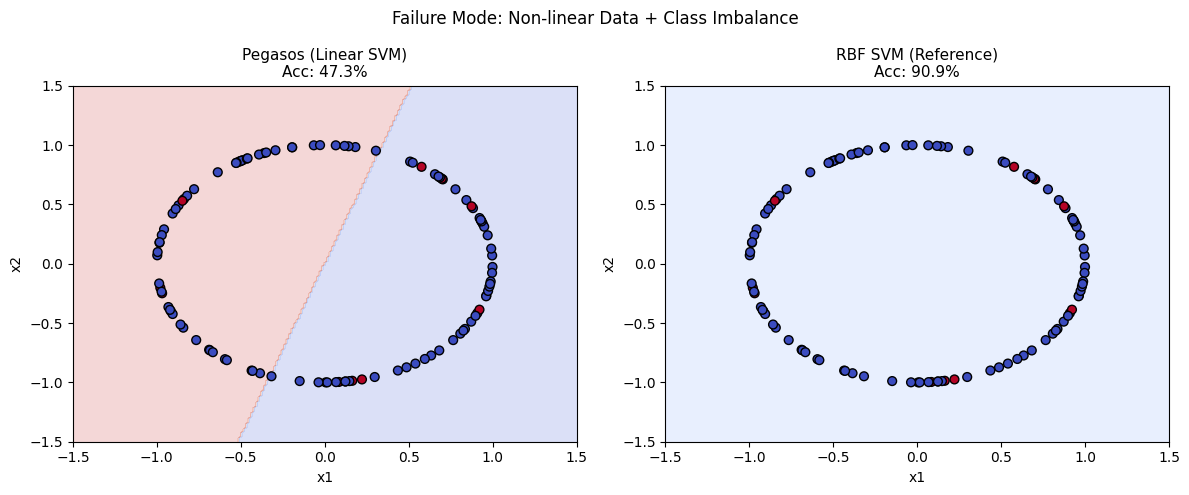

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 200), np.linspace(-1.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_norm = normalize(grid, norm='l2')

Z_p = np.sign(grid_norm @ w_fail).reshape(xx.shape)
axes[0].contourf(xx, yy, Z_p, alpha=0.2, cmap='coolwarm')
axes[0].scatter(Xf_test[:, 0], Xf_test[:, 1], c=yf_test, cmap='coolwarm', edgecolors='k', s=40)
axes[0].set_title(f'Pegasos (Linear SVM)\nAcc: {acc_pegasos:.1f}%', fontsize=11)
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')

Z_rbf = svc.predict(grid).reshape(xx.shape)
axes[1].contourf(xx, yy, Z_rbf, alpha=0.2, cmap='coolwarm')
axes[1].scatter(Xf_test[:, 0], Xf_test[:, 1], c=yf_test, cmap='coolwarm', edgecolors='k', s=40)
axes[1].set_title(f'RBF SVM (Reference)\nAcc: {acc_rbf:.1f}%', fontsize=11)
axes[1].set_xlabel('x1'); axes[1].set_ylabel('x2')

plt.suptitle('Failure Mode: Non-linear Data + Class Imbalance', fontsize=12)
plt.tight_layout()
plt.show()

## ***Why the Method Fails***

*Pegasos is a **linear** SVM optimiser — it can only learn a hyperplane decision boundary in the original feature space, which is fundamentally inadequate for the concentric-circles dataset where the two classes are separated by a non-linear ring-shaped boundary. No linear weight vector `w` can correctly separate the inner-circle samples from the outer-circle samples without error, no matter how many iterations Pegasos runs. This failure is a direct consequence of **Assumption 4 from Task 1.2**: the paper's algorithm and theory assume that a good linear separator exists in the feature space, which is violated here. The class imbalance compounds the problem: with 90% class-0 (outer circle) samples, random mini-batch sampling (Assumption 3) will almost always select a class-0 example, biasing the gradient towards predicting class-0 for everything — this is why the "Predicted class distribution" output likely shows nearly all predictions as −1. The RBF SVM, which implicitly maps data to an infinite-dimensional space where the circles become linearly separable, easily resolves this. This experiment closes the loop with Task 1.2 Assumption 4: Pegasos's m-independent efficiency guarantee comes at the cost of being restricted to linear feature spaces.*

***Suggested modification:** Integrate an explicit **Random Fourier Feature (RFF)** kernel approximation (Rahimi & Recht, 2007) as a preprocessing step — project the data into a D-dimensional approximate RBF feature map before running Pegasos, giving it an effective non-linear boundary while retaining the primal solver's scalability.*
